# 1. Install Dependencies and Setup

In [ ]:
!pip install tensorflow tensorflow-gpu opencv-python matplotlib

In [1]:
import os
import cv2
import tensorflow as tf
import cv2
import json
import numpy as np
from matplotlib import pyplot as plt

In [24]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

if gpus:
    print("GPUs available:")
    for gpu in gpus:
        print(f"- {gpu}")
else:
    print("No GPUs found.")

GPUs available:
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# 2. Load Data

### 2.1 Load Images

In [3]:
def load_image(x): 
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [4]:
train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (250,250)))
train_images = train_images.map(lambda x: x/255)

In [5]:
test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (250,250)))
test_images = test_images.map(lambda x: x/255)

In [6]:
val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg', shuffle=False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (250,250)))
val_images = val_images.map(lambda x: x/255)

### 2.2 Prepare Labels

In [7]:
def load_labels(label_path):
    with open(label_path.numpy(), 'r', encoding = "utf-8") as f:
        label = json.load(f)
    return [label['keypoints']]

In [8]:
train_labels = tf.data.Dataset.list_files('aug_data\\train\\labels\\*.json', shuffle=False)
train_labels = train_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.float16]))

In [9]:
test_labels = tf.data.Dataset.list_files('aug_data\\test\\labels\\*.json', shuffle=False)
test_labels = test_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.float16]))

In [10]:
val_labels = tf.data.Dataset.list_files('aug_data\\val\\labels\\*.json', shuffle=False)
val_labels = val_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.float16]))

### 2.3. Combine Labels and Images

In [25]:
train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(8)
train = train.prefetch(4)

In [26]:
test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1300)
test = test.batch(8)
test = test.prefetch(4)

In [27]:
val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1000)
val = val.batch(8)
val = val.prefetch(4)

### 2.4 View Samples

In [28]:
data_samples = train.as_numpy_iterator()

In [29]:
res = data_samples.next()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


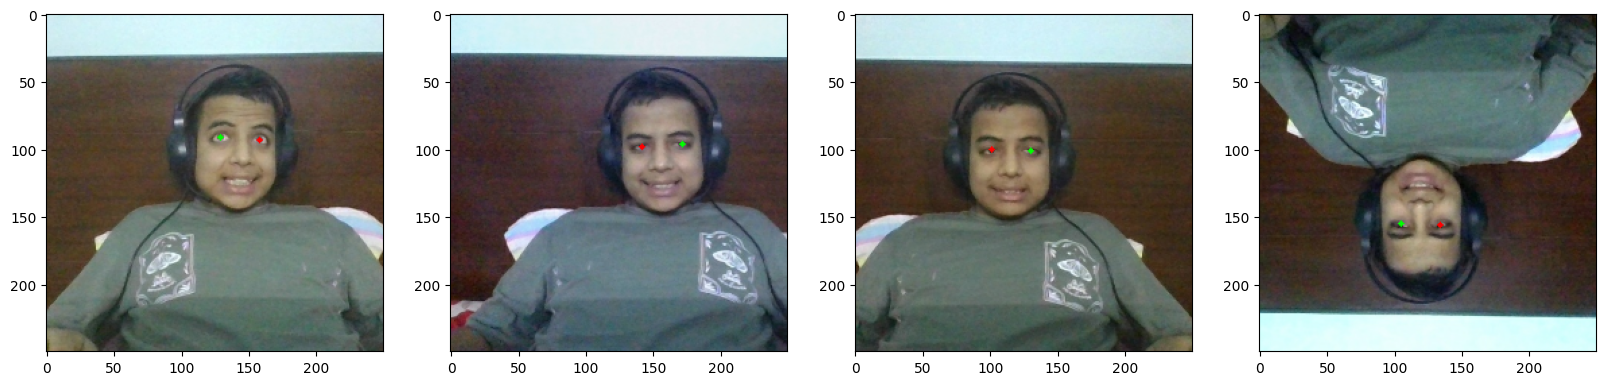

In [30]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    sample_image = res[0][idx]
    sample_coords = res[1][0][idx]
    
    cv2.circle(sample_image, tuple(np.multiply(sample_coords[:2], [250,250]).astype(int)), 2, (255,0,0), -1)
    cv2.circle(sample_image, tuple(np.multiply(sample_coords[2:], [250,250]).astype(int)), 2, (0,255,0), -1)
    
    ax[idx].imshow(sample_image)

# 3. Build Model

### 3.1 Create Neural Network

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, Reshape, Dropout
from tensorflow.keras.applications import ResNet152V2

In [32]:
model = Sequential([
    Input(shape=(250,250,3)), 
    ResNet152V2(include_top=False, input_shape=(250,250,3)),
    Conv2D(512, 3, padding='same', activation='relu'),
    Conv2D(512, 3, padding='same', activation='relu'),
    Conv2D(256, 3, 2, padding='same', activation='relu'),
    Conv2D(256, 2, 2, activation='relu'),
    Dropout(0.05),
    Conv2D(4, 2, 2),
    Reshape((4,))
])

In [33]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet152v2 (Functional)     (None, 8, 8, 2048)        58331648  
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 8, 8, 512)         9437696   
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 8, 8, 512)         2359808   
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 4, 4, 256)         1179904   
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 2, 2, 256)         262400    
_________________________________________________________________
dropout_1 (Dropout)          (None, 2, 2, 256)         0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 1, 1, 4)          

### 3.2 Setup Losses and Optimizer

In [34]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, decay=0.0007)
loss = tf.keras.losses.MeanSquaredError()

In [35]:
model.compile(optimizer, loss)

### 3.3 Train the Model

In [36]:
hist = model.fit(train, epochs=5, validation_data=val)

Epoch 1/5
765/765 [==============================] - 332s 388ms/step - loss: 0.7709 - val_loss: 0.0048
Epoch 2/5
765/765 [==============================] - 308s 375ms/step - loss: 0.0019 - val_loss: 3.9614e-04
Epoch 3/5
765/765 [==============================] - 304s 375ms/step - loss: 6.7883e-04 - val_loss: 1.9343e-04
Epoch 4/5
765/765 [==============================] - 304s 375ms/step - loss: 5.4903e-04 - val_loss: 3.1306e-04
Epoch 5/5
765/765 [==============================] - 304s 374ms/step - loss: 6.4824e-04 - val_loss: 2.6640e-04


# 4. Review Performance

### 4.1 View Loss Plots

In [37]:
hist.history

{'loss': [0.13407380878925323,
  0.0023143598809838295,
  0.0006134492577984929,
  0.0005022238474339247,
  0.0005050780018791556],
 'val_loss': [0.004812437109649181,
  0.00039614204433746636,
  0.00019342613813932985,
  0.0003130559634882957,
  0.00026640150463208556]}

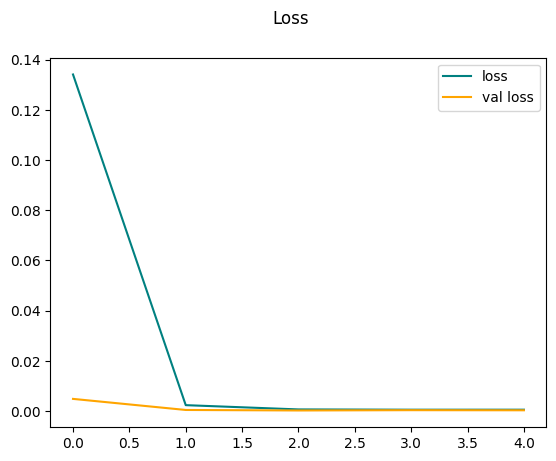

In [38]:
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val loss')
plt.suptitle('Loss')
plt.legend()
plt.show()

### 4.2. Make Predictions on Test

In [39]:
test_data = test.as_numpy_iterator()

In [40]:
test_sample = test_data.next()

In [41]:
yhat = model.predict(test_sample[0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


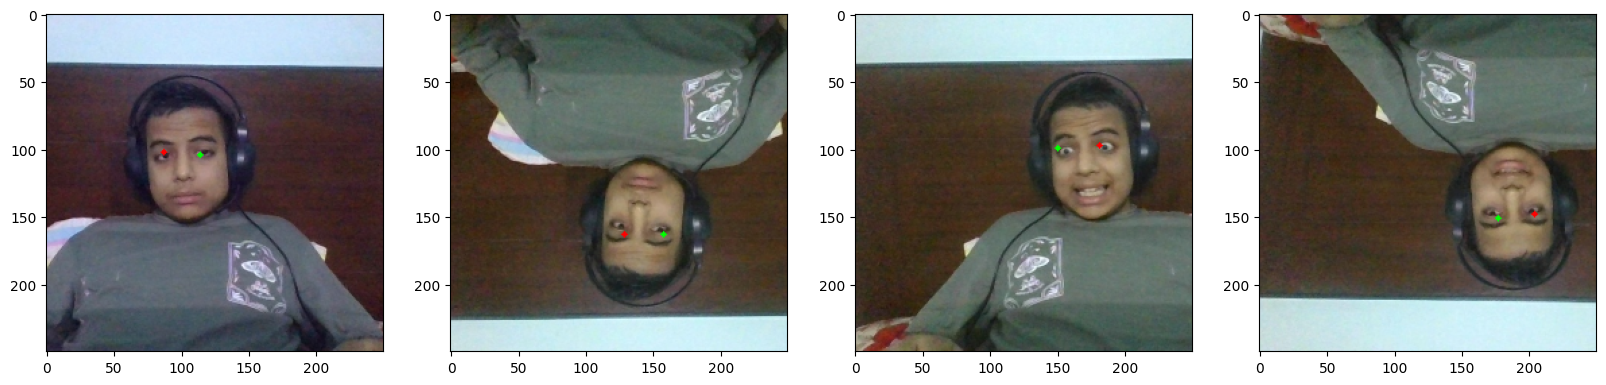

In [42]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    sample_image = test_sample[0][idx]
    sample_coords = yhat[idx]
    
    cv2.circle(sample_image, tuple(np.multiply(sample_coords[:2], [250,250]).astype(int)), 2, (255,0,0), -1)
    cv2.circle(sample_image, tuple(np.multiply(sample_coords[2:], [250,250]).astype(int)), 2, (0,255,0), -1)
    
    ax[idx].imshow(sample_image)

### 4.3. Save the Model

In [43]:
from tensorflow.keras.models import load_model

In [44]:
model.save('eye.h5')

In [45]:
model = load_model('eye.h5')

In [46]:
model.predict(test_sample[0])

array([[ 2.0378992e+01,  1.9160675e+01,  1.7850227e+01,  1.9864820e+01],
       [ 2.2729286e+01,  1.8428900e+01,  2.0005869e+01,  2.1763821e+01],
       [ 2.7431183e+01,  1.8198215e+01,  2.4864817e+01,  1.8964428e+01],
       [ 2.7427380e+01,  1.6538023e+01,  2.4474173e+01,  1.9056236e+01],
       [ 5.2720487e-01,  6.7223585e-01,  4.0194526e-01,  6.6370898e-01],
       [ 4.0263566e-01,  3.7059245e-01,  5.1184708e-01,  3.7999213e-01],
       [ 6.2015766e-01,  6.5371627e-01,  7.3424679e-01,  6.4937764e-01],
       [-4.5701265e-03, -3.5606744e-04, -1.4918353e-03, -4.9019419e-04]],
      dtype=float32)

# 5. Real Time Detection

In [47]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    _ , frame = cap.read()
    
    frame = frame[50:500,50:500,:] 
    rgb_img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb_img, (250,250))
    
    yhat = model.predict(np.expand_dims(resized/255,0))
    sample_coords = yhat[0,:4]
    
    cv2.circle(frame, tuple(np.multiply(sample_coords[:2], [450,450]).astype(int)), 2, (255,0,0), -1)
    cv2.circle(frame, tuple(np.multiply(sample_coords[2:], [450,450]).astype(int)), 2, (0,255,0), -1)
    
    cv2.imshow('EyeTrack', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()